# ✅ Solutions — Module 5 — Estimation, Maximum Likelihood & Confidence Intervals

Worked solutions for every exercise of this module. **Try the exercise yourself first** — you learn statistics by *doing* it. Each solution ends with a short interpretation, because in real projects the numbers are only half of the answer.

*Every exercise is self-contained: run the setup cell below, then jump to any exercise.*

In [1]:
# --- Course setup (identical in every module) ---
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.figsize": (9, 4.2), "figure.dpi": 90, "axes.titleweight": "bold",
                     "axes.spines.top": False, "axes.spines.right": False})
C = sns.color_palette("deep")      # C[0] blue, C[1] orange, C[2] green, C[3] red, C[4] purple
rng = np.random.default_rng(42)    # seeded generator => reproducible results

# --- additional tools for this module ---
from scipy.optimize import minimize, minimize_scalar
from statsmodels.stats.proportion import proportion_confint

### ✍️ Exercise 5.1 — *Bias, variance, MSE*: The German tank problem (Intelligence / competitive analysis)

In World War II the Allies estimated German tank production from the **serial numbers** of captured tanks — and the statisticians' estimates turned out to be far more accurate than those of conventional intelligence. Analysts use the same idea today to estimate a competitor's production volume from serial numbers of purchased devices.

Assume items are numbered $1,\dots,N$ and we observe $k$ serial numbers drawn at random without replacement. $N$ is unknown.

**Tasks**
1. For the captured `serials`, compute three candidate estimators: (a) $2\bar x - 1$, (b) the sample maximum $m$, (c) $m\,(1 + 1/k) - 1$.
2. Simulate 10,000 captures (same $N$ and $k$) and compare **bias, standard deviation and RMSE** of the three estimators. Plot their sampling distributions.
3. Why is (b) biased? Why is (c) so much better than (a), although both are unbiased?

In [2]:
g = np.random.default_rng(501)
N_true, k = 1380, 12                       # N_true is what the analyst wants to know
serials = np.sort(g.choice(np.arange(1, N_true + 1), size=k, replace=False))
print("captured serial numbers:", serials)

captured serial numbers: [  20  576  593  611  617  770  878 1044 1187 1232 1366 1371]


(a) 2·mean − 1      =    1710
(b) maximum         =    1371
(c) m·(1 + 1/k) − 1 =    1484     (truth: 1380)



,bias,std,RMSE
(a) 2·mean − 1,1.5,227.8,227.8
(b) maximum,-101.6,94.7,138.9
(c) m(1+1/k) − 1,3.9,102.6,102.7


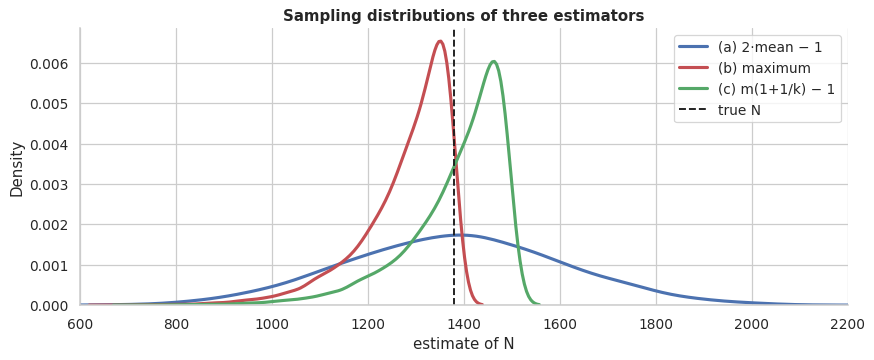

In [3]:
xbar, m = serials.mean(), serials.max()
print(f"(a) 2·mean − 1      = {2 * xbar - 1:7.0f}\n(b) maximum         = {m:7.0f}\n(c) m·(1 + 1/k) − 1 = {m * (1 + 1 / k) - 1:7.0f}     (truth: {N_true})\n")

caps = np.array([g.choice(N_true, size=k, replace=False) + 1 for _ in range(10_000)])
est = pd.DataFrame({"(a) 2·mean − 1": 2 * caps.mean(axis=1) - 1, "(b) maximum": caps.max(axis=1),
                    "(c) m(1+1/k) − 1": caps.max(axis=1) * (1 + 1 / k) - 1})
summary = pd.DataFrame({"bias": est.mean() - N_true, "std": est.std(), "RMSE": np.sqrt(((est - N_true) ** 2).mean())})
display(summary.round(1))

fig, ax = plt.subplots(figsize=(11, 4))
for col, c in zip(est.columns, [C[0], C[3], C[2]]):
    sns.kdeplot(est[col], ax=ax, color=c, lw=2.5, label=col, bw_adjust=1.3)
ax.axvline(N_true, color="k", ls="--", label="true N"); ax.set(xlabel="estimate of N", xlim=(600, 2200), title="Sampling distributions of three estimators"); ax.legend()
plt.show()

**Interpretation.**
* **(b)** the maximum can never exceed $N$, so all its errors go in one direction → biased low by about $N/(k+1) \approx 100$.
* **(a)** is unbiased (the mean of $1..N$ is $(N+1)/2$) but very noisy (std ≈ 230): it wastes information — it can even produce an estimate *smaller than the largest serial number we have seen*, which is logically impossible.
* **(c)** takes the maximum and adds the *average gap* between observed serial numbers. It is unbiased **and** has roughly half the spread of (a) → RMSE ≈ 100. It is in fact the minimum-variance unbiased estimator.

**Lesson:** unbiasedness alone is a weak criterion. Compare estimators by their whole sampling distribution (MSE) — and use the structure of the problem (here: the maximum is a *sufficient statistic*).

### ✍️ Exercise 5.2 — *Maximum likelihood*: How long do subscribers stay? (Subscription business / survival analysis)

A streaming service wants the **average customer lifetime**. The catch: many customers are still active — for them we only know that their lifetime is *at least* their current tenure (**right-censoring**). Averaging the lifetimes of the churned customers only is badly biased, because short lifetimes are over-represented among those already gone.

Assume exponential lifetimes with churn rate $\lambda$ (mean lifetime $1/\lambda$). A churned customer contributes the density $f(t)=\lambda e^{-\lambda t}$ to the likelihood, a still-active customer contributes the survival probability $S(t)=e^{-\lambda t}$:

$$\ell(\lambda) = \sum_{\text{churned}} \log\big(\lambda e^{-\lambda t_i}\big) + \sum_{\text{active}} \log\big(e^{-\lambda t_i}\big) = d\,\log\lambda - \lambda \sum_{\text{all}} t_i \qquad (d = \text{number of churned customers})$$

**Tasks**
1. Compute the naive estimate: mean observed lifetime of churned customers.
2. Code the censored log-likelihood, maximise it numerically (`minimize_scalar`) and compare with the closed form $\hat\lambda = d / \sum t_i$.
3. Plot $\ell(\lambda)$ and mark the MLE and the naive estimate.
4. Give a 95 % CI for the mean lifetime using $\operatorname{SE}(\hat\lambda) \approx \hat\lambda/\sqrt d$.
5. Estimate the 12-month retention rate $S(12)$.

In [4]:
g = np.random.default_rng(502)
n = 800
lifetime = g.exponential(14.0, n)                      # true mean lifetime: 14 months (unknown to the analyst)
tenure_limit = g.uniform(1, 18, n)                     # months since sign-up = how long we could observe each customer
subs = pd.DataFrame({"months_observed": np.minimum(lifetime, tenure_limit).round(2),
                     "churned": (lifetime <= tenure_limit).astype(int)})
print(subs.churned.value_counts().rename({1: "churned", 0: "still active (censored)"})); subs.head()

churned
still active (censored)    439
churned                    361
Name: count, dtype: int64


,months_observed,churned
0,3.41,1
1,4.32,0
2,6.76,0
3,8.50,0
4,8.69,0


naive mean lifetime (churned only):  4.60 months   <- badly biased
MLE numeric λ̂ = 0.06860,  closed form λ̂ = 0.06860  ->  mean lifetime = 14.58 months
95 % CI for the mean lifetime: [13.21, 16.25] months
estimated 12-month retention S(12) = 43.9%


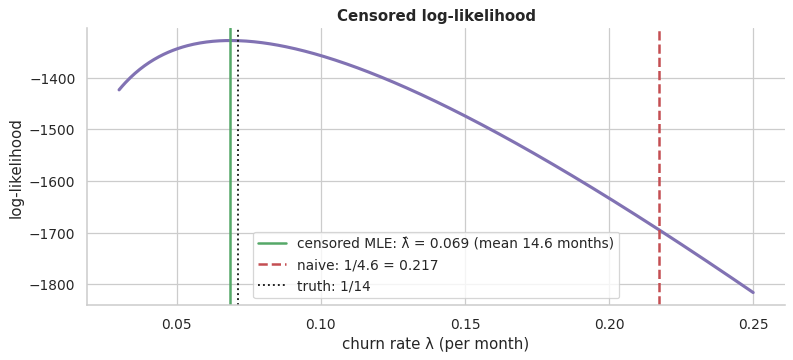

In [5]:
t, d = subs.months_observed.values, subs.churned.sum()
naive = subs.loc[subs.churned == 1, "months_observed"].mean()

def neg_loglik(lam):
    return -(d * np.log(lam) - lam * t.sum())

opt = minimize_scalar(neg_loglik, bounds=(1e-4, 2), method="bounded")
lam_hat = d / t.sum()
se = lam_hat / np.sqrt(d)
lam_lo, lam_hi = lam_hat - 1.96 * se, lam_hat + 1.96 * se
print(f"naive mean lifetime (churned only): {naive:5.2f} months   <- badly biased")
print(f"MLE numeric λ̂ = {opt.x:.5f},  closed form λ̂ = {lam_hat:.5f}  ->  mean lifetime = {1 / lam_hat:.2f} months")
print(f"95 % CI for the mean lifetime: [{1 / lam_hi:.2f}, {1 / lam_lo:.2f}] months")
print(f"estimated 12-month retention S(12) = {np.exp(-12 * lam_hat):.1%}")

lam = np.linspace(.03, .25, 400)
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(lam, -neg_loglik(lam), color=C[4], lw=2.5)
ax.axvline(lam_hat, color=C[2], lw=2, label=f"censored MLE: λ̂ = {lam_hat:.3f} (mean {1 / lam_hat:.1f} months)")
ax.axvline(1 / naive, color=C[3], lw=2, ls="--", label=f"naive: 1/{naive:.1f} = {1 / naive:.3f}")
ax.axvline(1 / 14, color="k", ls=":", label="truth: 1/14")
ax.set(xlabel="churn rate λ (per month)", ylabel="log-likelihood", title="Censored log-likelihood"); ax.legend(); plt.show()

**Interpretation.** The naive average (≈ 4.6 months) underestimates the true mean lifetime of 14 months by about two thirds: customers with long lifetimes are mostly *still active* and therefore missing from the churned group. The censored likelihood uses **every** customer — the active ones tell us "at least this long" — and recovers the truth (estimate ≈ 14.6 months, 95 % CI ≈ 13.2–16.3).

**Lesson:** the likelihood principle lets you use *partial* information correctly. The same logic powers survival analysis in medicine (Kaplan–Meier, Cox models), reliability engineering and warranty forecasting. The closed form $\hat\lambda = \text{events}/\text{total exposure time}$ is worth remembering: it is an *incidence rate*.

### ✍️ Exercise 5.3 — *CI for a mean & sample-size planning*: What is the average basket value? (Retail controlling)

A supermarket chain audits a random sample of 80 receipts from one store. Headquarters claims that "the average basket is worth €50".

**Tasks**
1. Compute the 95 % CI for the mean basket value by hand ($\bar x \pm t\cdot s/\sqrt n$) and check it with `stats.t.interval`.
2. The data is right-skewed. Validate the $t$-interval with a bootstrap percentile interval.
3. Is the headquarters' claim compatible with the data?
4. How many receipts are needed for a margin of error of ±€2 (95 %)?

In [6]:
g = np.random.default_rng(503)
basket = pd.Series(g.gamma(shape=2.2, scale=19, size=80).round(2), name="basket_eur")
basket.describe().round(2)

count     80.00
mean      39.92
std       28.45
min        3.03
25%       20.52
50%       33.68
75%       51.49
max      157.99
Name: basket_eur, dtype: float64

mean = 39.92 €, s = 28.45 €, SE = 3.18 €
95 % t-interval by hand : [33.59, 46.25]
95 % t-interval (scipy) : [33.59, 46.25]
95 % bootstrap interval : [34.09, 46.46]
skewness of the data = 1.77, of the bootstrap means = 0.24

required n for ±2 €: (1.96 · 28.4 / 2)² = 778 receipts


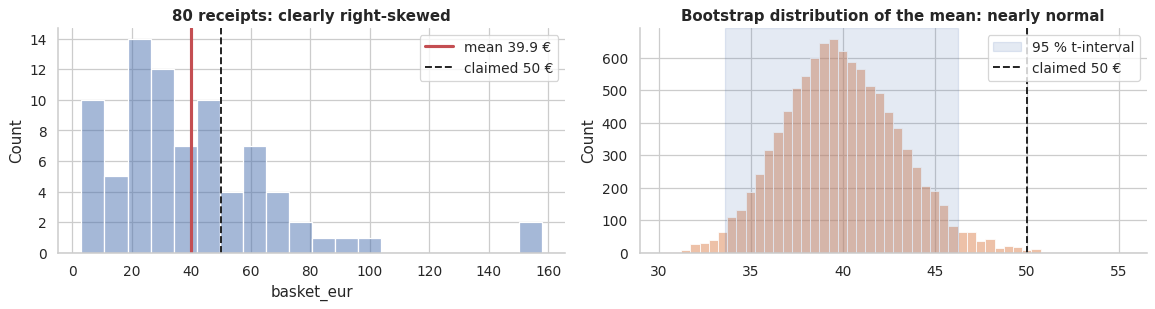

In [7]:
n, m, s = basket.size, basket.mean(), basket.std()
tcrit = stats.t.ppf(.975, n - 1); moe = tcrit * s / np.sqrt(n)
print(f"mean = {m:.2f} €, s = {s:.2f} €, SE = {s / np.sqrt(n):.2f} €")
print(f"95 % t-interval by hand : [{m - moe:.2f}, {m + moe:.2f}]")
lo, hi = stats.t.interval(.95, n - 1, loc=m, scale=stats.sem(basket)); print(f"95 % t-interval (scipy) : [{lo:.2f}, {hi:.2f}]")
boot = g.choice(basket.values, size=(10_000, n), replace=True).mean(axis=1)
print(f"95 % bootstrap interval : [{np.quantile(boot, .025):.2f}, {np.quantile(boot, .975):.2f}]")
print(f"skewness of the data = {stats.skew(basket):.2f}, of the bootstrap means = {stats.skew(boot):.2f}")
print(f"\nrequired n for ±2 €: (1.96 · {s:.1f} / 2)² = {np.ceil((1.96 * s / 2) ** 2):.0f} receipts")
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 3.6))
sns.histplot(basket, bins=20, color=C[0], alpha=.5, ax=a1); a1.axvline(m, color=C[3], lw=2.5, label=f"mean {m:.1f} €"); a1.axvline(50, color="k", ls="--", label="claimed 50 €"); a1.set_title("80 receipts: clearly right-skewed"); a1.legend()
sns.histplot(boot, bins=50, color=C[1], alpha=.5, ax=a2); a2.axvspan(m - moe, m + moe, color=C[0], alpha=.15, label="95 % t-interval"); a2.axvline(50, color="k", ls="--", label="claimed 50 €")
a2.set_title("Bootstrap distribution of the mean: nearly normal"); a2.legend(); plt.tight_layout(); plt.show()

**Interpretation.** Both intervals agree closely: although single baskets are clearly skewed, the *mean of 80* is already nearly normal (CLT — compare the two skewness values). The claim of €50 lies **above** the upper end of the interval, so it is not compatible with this store's data: either the store under-performs or the headquarters' figure is outdated or refers to another population. For a margin of ±€2 we would need several hundred receipts instead of 80 — precision grows only with $\sqrt n$.

### ✍️ Exercise 5.4 — *CI for a proportion*: Satisfaction rates and "zero defects" (Quality management)

**(a)** In a customer survey 412 of 500 respondents are satisfied. **(b)** A supplier delivers a first batch; you inspect 60 units and find **no defective unit**. The supplier concludes: "our defect rate is 0 %".

**Tasks**
1. For (a), compute the Wald and the Wilson 95 % interval. Do they differ much? Why (not)?
2. For (b), compute Wald, Wilson and Clopper–Pearson intervals and compare the upper limits with the *rule of three*.
3. How many consecutive defect-free units would you need to inspect to claim "defect rate below 1 %" with 95 % confidence?

In [8]:
k_a, n_a = 412, 500       # (a) satisfied customers
k_b, n_b = 0, 60          # (b) defective units

(a) 412/500
   Wald            : [0.7906, 0.8574]
   Wilson          : [0.7882, 0.8549]
   Clopper–Pearson : [0.7877, 0.8564]
(b) 0/60
   Wald            : [0.0000, 0.0000]
   Wilson          : [0.0000, 0.0602]
   Clopper–Pearson : [0.0000, 0.0596]

rule of three for 0/60: upper bound ≈ 3/60 = 0.050
exact one-sided 95 % bound: 1 − 0.05^(1/60) = 0.0487
defect-free units needed to show p < 1 %: 299   (rule of three: 3/0.01 = 300)


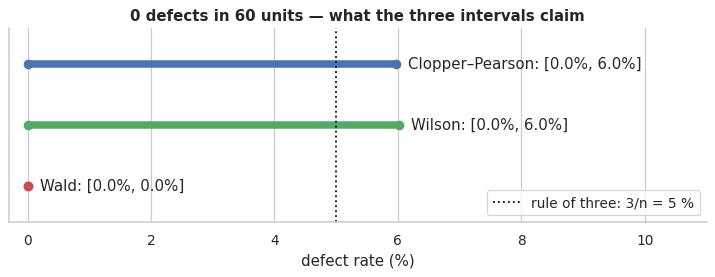

In [9]:
for label, k, n in [("(a) 412/500", k_a, n_a), ("(b) 0/60", k_b, n_b)]:
    print(label)
    for method, name in [("normal", "Wald"), ("wilson", "Wilson"), ("beta", "Clopper–Pearson")]:
        lo, hi = proportion_confint(k, n, alpha=.05, method=method)
        print(f"   {name:16s}: [{lo:.4f}, {hi:.4f}]")
print(f"\nrule of three for 0/60: upper bound ≈ 3/60 = {3 / 60:.3f}")
print(f"exact one-sided 95 % bound: 1 − 0.05^(1/60) = {1 - .05 ** (1 / 60):.4f}")
n_needed = int(np.ceil(np.log(.05) / np.log(.99)))
print(f"defect-free units needed to show p < 1 %: {n_needed}   (rule of three: 3/0.01 = 300)")
fig, ax = plt.subplots(figsize=(10, 2.8))
for i, (method, name) in enumerate([("normal", "Wald"), ("wilson", "Wilson"), ("beta", "Clopper–Pearson")]):
    lo, hi = proportion_confint(k_b, n_b, alpha=.05, method=method); col = [C[3], C[2], C[0]][i]
    ax.plot([lo * 100, hi * 100], [i, i], lw=6, color=col, solid_capstyle="butt"); ax.scatter([lo * 100, hi * 100], [i, i], color=col, s=45, zorder=3); ax.text(hi * 100 + .2, i, f"{name}: [{lo:.1%}, {hi:.1%}]", va="center")
ax.axvline(5, color="k", ls=":", label="rule of three: 3/n = 5 %"); ax.set(yticks=[], xlim=(-.3, 11), ylim=(-.6, 2.6), xlabel="defect rate (%)", title="0 defects in 60 units — what the three intervals claim"); ax.legend(loc="lower right"); plt.show()

**Interpretation.** (a) With $n=500$ and $\hat p = 0.82$ far from 0 and 1, all methods agree to within half a percentage point (≈ 79 %–85 %) — here Wald is fine. (b) With zero events Wald returns the nonsensical interval [0, 0], i.e. "we are certain the defect rate is exactly zero". Wilson and Clopper–Pearson tell the truth: defect rates up to about 5–6 % are compatible with 60 clean units. The *rule of three* (3/n = 5 %) reproduces the exact one-sided bound almost perfectly.

**Lesson:** *absence of evidence is not evidence of absence.* To demonstrate a defect rate below 1 % you need about **300** consecutive defect-free units — a number every quality engineer and every clinical-safety reviewer should know.

### ✍️ Exercise 5.5 — *Bootstrap*: Did the new recommendation engine lift revenue per visitor? (E-commerce A/B test)

Revenue per visitor is a nasty metric: ~95 % of visitors buy nothing (zeros) and buyers' spend is heavily right-skewed. Management wants the **relative lift** $\;(\bar x_{variant} - \bar x_{control})/\bar x_{control}$ with an uncertainty statement. There is no simple formula for the CI of such a ratio — a job for the bootstrap.

**Tasks**
1. Compute revenue per visitor in both groups and the observed relative lift.
2. Bootstrap the relative lift (resample **each group separately**, $B = 4{,}000$) and report the 95 % percentile interval.
3. Plot the bootstrap distribution. In what share of resamples is the lift positive?
4. What do you tell management?

In [10]:
g = np.random.default_rng(505)
def simulate_revenue(n, p_buy, mu):                          # most visitors buy nothing; buyers spend a log-normal amount
    return np.where(g.random(n) < p_buy, g.lognormal(mu, 1.0, n), 0).round(2)
control, variant = simulate_revenue(12_000, .050, 3.60), simulate_revenue(12_000, .056, 3.65)
print(f"buyers: control {np.mean(control > 0):.2%}, variant {np.mean(variant > 0):.2%};  largest single order: {max(control.max(), variant.max()):,.0f} €")

buyers: control 4.97%, variant 5.51%;  largest single order: 767 €


revenue per visitor: control 2.639 €, variant 3.617 €  ->  observed lift +37.1%


bootstrap SE = 11.6%,  95 % CI for the lift = [+17.0%, +61.6%],  share of resamples with lift > 0: 100.0%


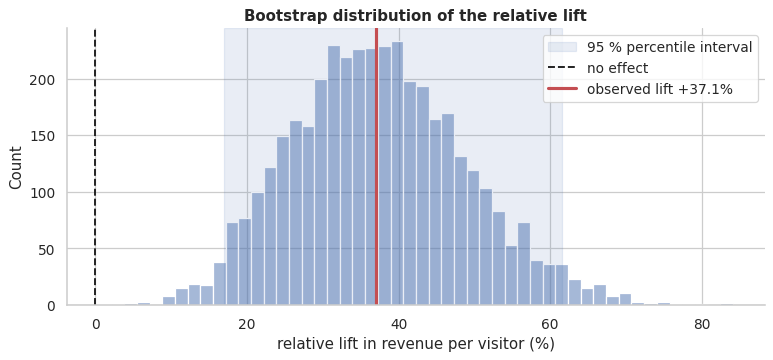

In [11]:
lift = variant.mean() / control.mean() - 1
print(f"revenue per visitor: control {control.mean():.3f} €, variant {variant.mean():.3f} €  ->  observed lift {lift:+.1%}")

B = 4000
boot = np.array([g.choice(variant, variant.size).mean() / g.choice(control, control.size).mean() - 1 for _ in range(B)])
lo, hi = np.quantile(boot, [.025, .975])
print(f"bootstrap SE = {boot.std():.1%},  95 % CI for the lift = [{lo:+.1%}, {hi:+.1%}],  share of resamples with lift > 0: {(boot > 0).mean():.1%}")

fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(boot * 100, bins=50, color=C[0], alpha=.5, ax=ax); ax.axvspan(lo * 100, hi * 100, color=C[0], alpha=.12, label="95 % percentile interval")
ax.axvline(0, color="k", ls="--", label="no effect"); ax.axvline(lift * 100, color=C[3], lw=2.5, label=f"observed lift {lift:+.1%}")
ax.set(xlabel="relative lift in revenue per visitor (%)", title="Bootstrap distribution of the relative lift"); ax.legend(); plt.show()

**Interpretation.** The observed lift is about +37 %, and the whole 95 % interval (≈ +17 % to +62 %) lies above zero — the variant is better. But look at the *width*: 45 percentage points. A handful of very large orders dominate the mean, so revenue per visitor is a noisy metric even with 12,000 visitors per arm. An honest message to management: *"The new engine increases revenue per visitor. The size of the gain is still uncertain — plan the business case with the lower end of the interval (+17 %), not with the headline number."* (The simulation's true lift is ≈ +18 %: the point estimate overshoots, as lucky point estimates of winning variants tend to do.)

**Lesson:** the bootstrap gives an uncertainty statement for *any* statistic — but it cannot make a noisy metric precise. Resampling each group separately respects the design (two independent samples).